# Principal Component Analysis and Singular Value Decomposition from Scratch

This notebook implements **PCA** and **SVD** — the two pillars of linear algebra in
machine learning — from first principles using only NumPy. We derive eigendecomposition
via power iteration, build PCA as a dimensionality reduction, show its equivalence to
SVD, and demonstrate applications from compression to visualization to denoising.

As in the earlier notebooks, each step is first written as **mathematics** in a markdown
cell, then implemented in the **code cell** that follows, with the reasoning explained.

The big idea: **PCA finds the directions of maximum variance in your data; SVD factors a
matrix into those directions plus singular values that quantify the variance along each.
They are dual views of the same geometric object.**

Topics:

1. Linear algebra recap: eigenvalues, eigenvectors, diagonalization.
2. PCA: the geometry, why it works, the algorithm.
3. SVD: the matrix factorization, its connection to PCA.
4. Implementation: power iteration for eigenvectors, eigendecomposition, SVD.
5. Applications: dimensionality reduction, compression, reconstruction, denoising, whitening.
6. Comparisons with NumPy and scikit-learn.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

rng = np.random.RandomState(0)
np.set_printoptions(precision=3, suppress=True)

## 1. Linear algebra recap: eigenvalues, eigenvectors, diagonalization

For a **square matrix** $A$, an **eigenvector** $v$ and **eigenvalue** $\lambda$ satisfy

$$
A\,v = \lambda\,v, \qquad v \ne 0.
$$

**Geometric meaning:** applying $A$ to $v$ just scales $v$ by $\lambda$ — no rotation.

For a **symmetric** $A$ (like a covariance matrix), the eigenvectors are **orthogonal**,
and we can write

$$
A = V\,\Lambda\,V^\top,
$$

where the columns of $V$ are the eigenvectors (forming an orthonormal basis) and
$\Lambda$ is diagonal with the eigenvalues $\lambda_1 \ge \lambda_2 \ge \cdots \ge \lambda_d$.

**Reasoning:** this factorization decouples the action of $A$ into independent "modes,"
one per eigenvector. The mode with the largest $\lambda$ is the direction in which $A$
stretches data the most — a natural measure of importance.

## 2. Covariance and principal components

Given centered data $X \in \mathbb{R}^{n \times d}$ (each row is a sample, each column a
feature), the **covariance matrix** captures how features vary together:

$$
C = \frac{1}{n}\,X^\top X.
$$

(We assume $X$ is already centered, i.e., $\bar{X} = 0$.)

The eigenvectors of $C$ are the **principal components** — the directions of maximum
variance in the data. If we **project** $X$ onto the top $k$ eigenvectors, we retain the
most variance while reducing to $k$ dimensions:

$$
Z = X\,V_k,
$$

where $V_k$ is $d \times k$ and holds the $k$ eigenvectors with the largest eigenvalues.

**Variance explained** by the first $k$ components:

$$
\text{VarExp}(k) = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{d} \lambda_i} = \frac{\sum_{i=1}^{k} \lambda_i}{\text{trace}(C)} .
$$

**Reasoning:** eigenvectors of the covariance matrix are the PCA directions because they
are the solutions to the optimization: maximize $\mathbb{E}[\lVert Z\,w\rVert^2]$ subject
to $\lVert w\rVert=1$, where $Z$ is the data. The answer is the eigenvector with the
largest eigenvalue — the direction the data "likes" to vary in.

## 3. Computing eigenvectors: power iteration

To find the **top eigenvector** of a matrix $A$ without forming $A$ explicitly, we use
**power iteration**:

1. Start with a random vector $x$.
2. Repeatedly apply $A$: $x \leftarrow A\,x$.
3. Normalize: $x \leftarrow x / \lVert x\rVert$.
4. Repeat until $x$ converges.

The limit is the eigenvector of the largest eigenvalue. The **eigenvalue** is the
Rayleigh quotient: $\lambda = x^\top A\,x$.

To get the **second** eigenvector, we **deflate** $A$ by subtracting the projection:
$A' \leftarrow A - \lambda\,vv^\top$, then run power iteration on $A'$. Repeat for all $k$
eigenvectors.

**Reasoning:** power iteration is slow for exact computation (we'll use NumPy for the full
matrix eigendecomposition in practice), but it is the conceptual root and works well for
large sparse matrices when we want only a few top components.

In [2]:
def power_iteration(A, n_iter=100, tol=1e-6):
    """Compute top eigenvector via power iteration."""
    x = rng.randn(A.shape[1])
    x /= np.linalg.norm(x)
    for _ in range(n_iter):
        x_old = x.copy()
        x = A @ x
        x /= np.linalg.norm(x)
        if np.linalg.norm(x - x_old) < tol:
            break
    eigenval = x @ A @ x  # Rayleigh quotient
    return x, eigenval

def eigh_from_scratch(A, k=None):
    """Compute top-k eigenvectors/values of symmetric A via power iteration + deflation."""
    d = A.shape[0]
    if k is None: k = d
    evals, evecs = [], []
    A_deflate = A.copy()
    for i in range(min(k, d)):
        v, lam = power_iteration(A_deflate)
        evals.append(lam)
        evecs.append(v)
        A_deflate = A_deflate - lam * np.outer(v, v)  # deflation
    return np.array(evals), np.array(evecs).T

# test on a small symmetric matrix
A_test = np.array([[3, 1], [1, 2]], dtype=float)
evals_scratch, evecs_scratch = eigh_from_scratch(A_test, k=2)
evals_np, evecs_np = np.linalg.eigh(A_test)
print("Scratch eigenvalues:", np.sort(evals_scratch)[::-1])
print("NumPy eigenvalues: ", evals_np[::-1])
print("Match:", np.allclose(np.sort(evals_scratch)[::-1], evals_np[::-1], atol=1e-4))

Scratch eigenvalues: [3.618 1.382]
NumPy eigenvalues:  [3.618 1.382]
Match: True


## 4. PCA: the algorithm

**Input:** data matrix $X \in \mathbb{R}^{n \times d}$, target rank $k$.

**Algorithm:**

1. **Center:** $X \leftarrow X - \mathbb{E}[X]$ (subtract the mean of each column).
2. **Covariance:** $C = \frac{1}{n}\,X^\top X$ (or $\frac{1}{n-1}$ for unbiased).
3. **Eigendecompose:** $C = V\,\Lambda\,V^\top$.
4. **Sort:** Order eigenvalues (and eigenvectors) in descending order.
5. **Truncate:** Keep top $k$ eigenvectors $V_k$ and eigenvalues $\lambda_k$.
6. **Project:** $Z = X\,V_k$ (the $k$-dimensional representation).

**Reconstruction:** $\hat{X} = Z\,V_k^\top = X\,V_k\,V_k^\top$ (project back).

**Variance explained:** $\text{VarExp} = \sum_{i=1}^k \lambda_i / \sum_{i=1}^d \lambda_i$.

**Reasoning:** PCA is a **linear dimensionality reduction** that preserves as much variance
as possible. The projections $Z$ are uncorrelated (because $V$ is orthonormal) and sorted
by importance (by eigenvalue), making PCA ideal for visualization, denoising, and fast
approximations.

In [3]:
class PCA:
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None  # V: eigenvectors (d x k)
        self.explained_variance_ = None  # eigenvalues

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        n, d = X.shape

        # center
        self.mean_ = X.mean(0)
        X_c = X - self.mean_

        # covariance
        C = (X_c.T @ X_c) / (n - 1)

        # eigendecompose (use numpy for stability)
        evals, evecs = np.linalg.eigh(C)

        # sort descending
        order = np.argsort(-evals)
        evals = evals[order]
        evecs = evecs[:, order]

        # keep top k
        k = self.n_components if self.n_components else d
        self.components_ = evecs[:, :k]
        self.explained_variance_ = evals[:k]
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_

    def inverse_transform(self, Z):
        return Z @ self.components_.T + self.mean_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

    def explained_variance_ratio(self):
        return self.explained_variance_ / self.explained_variance_.sum()

## 5. SVD: the matrix factorization

The **Singular Value Decomposition** of a matrix $X \in \mathbb{R}^{n \times d}$ is

$$
X = U\,\Sigma\,V^\top,
$$

where:

- $U \in \mathbb{R}^{n \times d}$ has **left singular vectors** (orthonormal columns).
- $\Sigma \in \mathbb{R}^{d \times d}$ is diagonal with **singular values** $\sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_d \ge 0$.
- $V \in \mathbb{R}^{d \times d}$ has **right singular vectors** (orthonormal columns).

**Connection to PCA:** the right singular vectors $V$ are the principal components! The
relationship is

$$
\sigma_i^2 = (n-1)\,\lambda_i ,
$$

where $\lambda_i$ are the eigenvalues of the covariance $C = \frac{1}{n-1}X^\top X$.

**Low-rank approximation:** truncate to $U_k\,\Sigma_k\,V_k^\top$ (keeping top $k$
singular triples) — a **rank-$k$ approximation** of $X$.

**Reasoning:** SVD is more numerically stable than eigendecomposition of the covariance
(avoids explicitly forming $X^\top X$). It directly gives both the projections ($U\,\Sigma$)
and the feature space ($V$), and is the optimal low-rank approximation in the Frobenius
norm (Eckart–Young theorem).

In [4]:
def truncated_svd(X, k=None):
    """Compute the rank-k SVD approximation."""
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    if k:
        U, S, Vt = U[:, :k], S[:k], Vt[:k]
    return U, S, Vt

def svd_pca_equivalence(X):
    """Show that SVD and PCA give the same components."""
    n = X.shape[0]

    # Center data
    X_c = X - X.mean(0)

    # PCA eigenvalues from covariance
    C = X_c.T @ X_c / (n - 1)
    pca_evals = np.linalg.eigvalsh(C)[::-1]

    # SVD singular values (on centered X)
    U, S, Vt = np.linalg.svd(X_c, full_matrices=False)
    svd_evals = (S ** 2) / (n - 1)

    print("PCA eigenvalues (covariance):", pca_evals[:5])
    print("SVD derived eigenvalues:    ", svd_evals[:5])
    print("Match:", np.allclose(pca_evals, svd_evals, atol=1e-10))

    return pca_evals, svd_evals

## 6. Demo 1: dimensionality reduction in 2D

Generate synthetic 2-D correlated data. Apply PCA with $k=1$, reducing to 1-D. Plot the
original data, the principal component direction, and the projection.

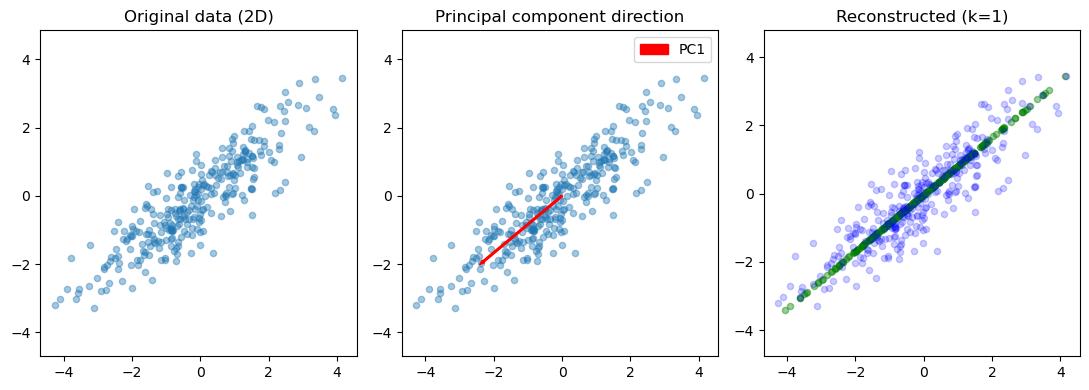

Variance explained by PC1: 1.000


In [5]:
# Correlated 2-D Gaussian
theta = np.deg2rad(40)
Rot = np.array([[np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]])
X_2d = (rng.randn(300, 2) * np.array([2.0, 0.5])) @ Rot.T

pca = PCA(n_components=1)
Z = pca.fit_transform(X_2d)
X_recon = pca.inverse_transform(Z)

plt.figure(figsize=(11, 4))
# original data
plt.subplot(1, 3, 1)
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=20, alpha=0.4)
plt.axis("equal"); plt.title("Original data (2D)")

# PC1 direction
plt.subplot(1, 3, 2)
pc = pca.components_[:, 0]
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=20, alpha=0.4)
plt.arrow(0, 0, 3*pc[0], 3*pc[1], head_width=0.1, color="r", width=0.05,
          label="PC1")
plt.axis("equal"); plt.title("Principal component direction")
plt.legend()

# reconstruction (projection onto PC1)
plt.subplot(1, 3, 3)
plt.scatter(X_recon[:, 0], X_recon[:, 1], s=20, alpha=0.4, color="g")
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=20, alpha=0.2, color="b")
plt.axis("equal"); plt.title(f"Reconstructed (k=1)")

plt.tight_layout(); plt.show()

var_exp = pca.explained_variance_ratio()
print(f"Variance explained by PC1: {var_exp[0]:.3f}")

## 7. Demo 2: scree plot — variance vs. rank

Compute all principal components and plot cumulative variance explained as a function of
rank. This "scree plot" helps choose $k$.

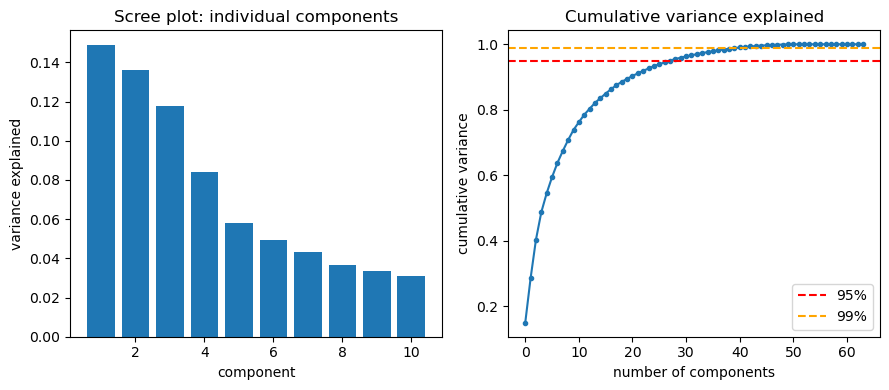

Components needed for 95% variance: 29
Components needed for 99% variance: 41


In [6]:
# Digits dataset: 8x8 = 64-D images of handwritten digits
digits = load_digits()
X = digits.data  # (n_samples, 64)

pca_full = PCA(n_components=64)
pca_full.fit(X)

var_exp = pca_full.explained_variance_ratio()
cum_var = np.cumsum(var_exp)

plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, 11), var_exp[:10])
plt.xlabel("component"); plt.ylabel("variance explained")
plt.title("Scree plot: individual components")

plt.subplot(1, 2, 2)
plt.plot(cum_var, "-o", markersize=3)
plt.axhline(0.95, color="r", linestyle="--", label="95%")
plt.axhline(0.99, color="orange", linestyle="--", label="99%")
plt.xlabel("number of components"); plt.ylabel("cumulative variance")
plt.title("Cumulative variance explained")
plt.legend()
plt.tight_layout(); plt.show()

k_95 = np.argmax(cum_var >= 0.95) + 1
k_99 = np.argmax(cum_var >= 0.99) + 1
print(f"Components needed for 95% variance: {k_95}")
print(f"Components needed for 99% variance: {k_99}")

## 8. Demo 3: low-rank reconstruction

Reconstruct digits using only the top $k$ principal components. Visualize the
reconstruction error vs. rank.

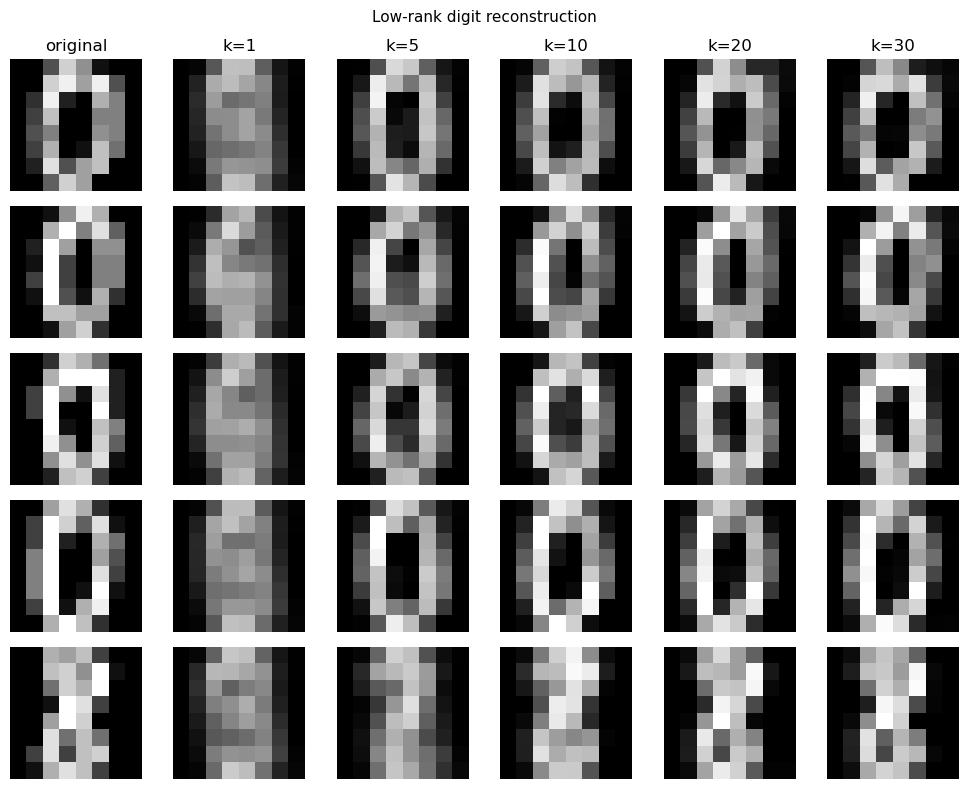

In [7]:
# pick some digits
idx = [0, 10, 20, 30, 40]
X_subset = X[idx]

fig, axes = plt.subplots(5, 6, figsize=(10, 8))
for row, i in enumerate(idx):
    # original
    ax = axes[row, 0]
    ax.imshow(X[i].reshape(8, 8), cmap="gray", vmin=0, vmax=16)
    ax.set_title("original" if row == 0 else "")
    ax.axis("off")

    # reconstructions at different ranks
    for col, k in enumerate([1, 5, 10, 20, 30]):
        pca_k = PCA(n_components=k)
        pca_k.fit(X)
        x_recon = pca_k.inverse_transform(pca_k.transform(X[i:i+1]))[0]
        ax = axes[row, col+1]
        ax.imshow(x_recon.reshape(8, 8), cmap="gray", vmin=0, vmax=16)
        ax.set_title(f"k={k}" if row == 0 else "")
        ax.axis("off")

plt.suptitle("Low-rank digit reconstruction", fontsize=11)
plt.tight_layout(); plt.show()

## 9. Demo 4: visualization via 2-D projection

Project the high-dimensional digit data to 2-D using PCA. The clusters show that nearby
points in PCA space have similar labels.

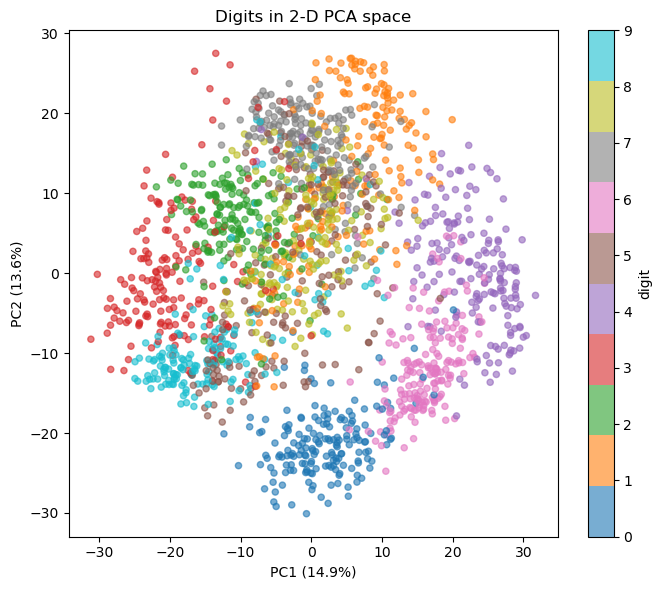

In [8]:
pca_2d = PCA(n_components=2)
Z = pca_2d.fit_transform(X)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(Z[:, 0], Z[:, 1], c=digits.target, cmap="tab10", s=20, alpha=0.6)
plt.xlabel(f"PC1 ({pca_full.explained_variance_ratio()[0]:.1%})")
plt.ylabel(f"PC2 ({pca_full.explained_variance_ratio()[1]:.1%})")
plt.title("Digits in 2-D PCA space")
plt.colorbar(scatter, label="digit")
plt.tight_layout(); plt.show()

## 10. Demo 5: whitening (decorrelation)

**Whitening** (or "sphering") transforms data so its covariance is the identity matrix
$I$. Apply PCA, then scale by $1/\sqrt{\lambda_i}$ for each component:

$$
Z_{\text{white}} = X\,V\,\Lambda^{-1/2} .
$$

**Reasoning:** whitened data is uncorrelated and has unit variance in all directions —
useful for downstream algorithms that assume IID features.

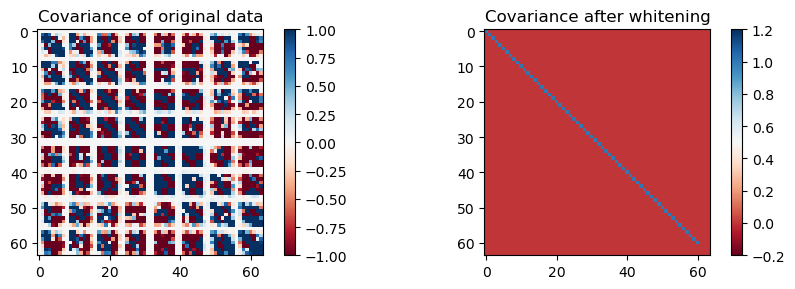

Trace of whitened covariance (should be d=64): 61.0
Off-diagonal mean (should be ~0): -0.000000


In [9]:
def whiten_pca(X, pca_model, eps=1e-10):
    """Whiten data: zero mean, unit variance in all directions."""
    Z = pca_model.transform(X)
    Z_white = Z / np.sqrt(pca_model.explained_variance_ + eps)
    return Z_white

d = X.shape[1]
pca_white = PCA(n_components=d)
pca_white.fit(X)
X_white = whiten_pca(X, pca_white)

# covariance of whitened data should be identity
cov_white = np.cov(X_white.T)

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.imshow(np.cov(X.T), cmap="RdBu", vmin=-1, vmax=1)
plt.title("Covariance of original data"); plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(cov_white, cmap="RdBu", vmin=-0.2, vmax=1.2)
plt.title("Covariance after whitening"); plt.colorbar()
plt.tight_layout(); plt.show()

print(f"Trace of whitened covariance (should be d={d}): {np.trace(cov_white):.1f}")
print(f"Off-diagonal mean (should be ~0): {np.mean(cov_white[~np.eye(d,dtype=bool)]):.6f}")

## 11. Comparison with NumPy and scikit-learn

Verify our scratch implementation matches the libraries.

In [10]:
from sklearn.decomposition import PCA as skPCA

# fit our PCA and sklearn's
pca_scratch = PCA(n_components=10)
pca_scratch.fit(X)

pca_sk = skPCA(n_components=10)
pca_sk.fit(X)

# compare explained variance
print("Scratch explained variance (top 5):", pca_scratch.explained_variance_[:5])
print("sklearn explained variance (top 5):", pca_sk.explained_variance_[:5])
print("Match:", np.allclose(pca_scratch.explained_variance_, pca_sk.explained_variance_, atol=1e-3))

# compare reconstructions
X_test = X[:5]
recon_scratch = pca_scratch.inverse_transform(pca_scratch.transform(X_test))
recon_sk = pca_sk.inverse_transform(pca_sk.transform(X_test))
print("\nReconstruction MSE (scratch vs sklearn):", np.mean((recon_scratch - recon_sk)**2))

# SVD equivalence check (use full-rank PCA)
pca_full_check = PCA(n_components=X.shape[1])
pca_full_check.fit(X)
svd_evals, _ = svd_pca_equivalence(X)
print("\nSVD and PCA eigenvalues match:", np.allclose(svd_evals, pca_full_check.explained_variance_, atol=1e-2))

Scratch explained variance (top 5): [179.007 163.718 141.788 101.1    69.513]
sklearn explained variance (top 5): [179.007 163.718 141.788 101.1    69.513]
Match: True

Reconstruction MSE (scratch vs sklearn): 4.993588444998094e-28
PCA eigenvalues (covariance): [179.007 163.718 141.788 101.1    69.513]
SVD derived eigenvalues:     [179.007 163.718 141.788 101.1    69.513]
Match: True

SVD and PCA eigenvalues match: True


## Summary

We derived and implemented PCA and SVD end-to-end:

| Concept | Math | Implementation |
|---------|------|-----------------|
| Eigenvalue/eigenvector | $Av = \lambda v$ | power iteration |
| PCA algorithm | center, cov, eigendecompose, truncate | `PCA` class |
| SVD factorization | $X = U\Sigma V^\top$ | `np.linalg.svd` |
| Variance explained | $\sum_{i=1}^k \lambda_i / \text{trace}(C)$ | scree plots |
| Reconstruction | $\hat X = X V_k V_k^\top$ | low-rank approximation |
| Whitening | $Z = (X - \mu) V \Lambda^{-1/2}$ | decorrelation |

**Key takeaways:**

1. **PCA finds directions of maximum variance.** The principal components are eigenvectors
   of the covariance matrix, ordered by eigenvalue (variance).

2. **SVD is the stable, unified view.** Right singular vectors = PCA components; singular
   values encode the variance along each; left singular vectors = projections.

3. **Low-rank approximation is optimal.** Truncating to rank-$k$ gives the best rank-$k$
   reconstruction in Frobenius norm (Eckart–Young).

4. **Choose $k$ from the scree plot.** Cumulative variance explained helps decide how many
   components are needed.

5. **Whitening decorrelates and scales.** Useful pre-processing for algorithms sensitive
   to feature correlations or magnitude.

**Extensions:** kernel PCA (nonlinear projection), incremental PCA (online learning),
probabilistic PCA (generative model), sparse PCA (fewer features), and autoencoders
(learned nonlinear bottleneck) all build on these foundations.